## **Historical Perspectives on Current Economic Issues: Big Data and Applications**
### *AI/ML for language and vision*

Torben Skov Dyg Johansen (tsdj@sam.sdu.dk, tsdj@rooftop-analytics.com)
Assistant Professor of Econometrics and Data Science at SDU and Data Scientist at Rooftop Analytics
https://torbensdjohansen.github.io/

Christian Vedel (christian-vs@sam.sdu.dk)
Assistant Professor of Economic History
https://sites.google.com/view/christianvedel 

# Today
- Taking the plunch into using some of the tools
- Balance between showing *what* can be done and *how* to do it. More towards *how*. 
- First bit should be fine for everyone to follow along, but difficulty increases througout the day

### Plan:
1. **Off-shelf-models:** How to run advanced ML pipelines for text and image analysis in a couple lines of code
2. **Tokens and embedding space:** A conceptual framework to understand machine learning
3. **Introduction to OccCANINE:** How to use it and how to build something similar (a neural network for text classication)
4. **Transcription:** How to run transcription on scanned documents

# Python

- The single most important language for machine learning
- R can do *some* stuff. But everything we show you today
- Easy language

![Languages](Figures/languages.png)

![Frameworks](Figures/frameworks.png)


## Getting started with Python

### Colab
- We will use google colab: https://colab.research.google.com/ 

### Proper setup
- Install anaconda
- Make environment `conda create --name my_env`
- `conda install spyder`
- Find *plenty* via google

### Programming logic
- Play "The Farmer Was Replaced": https://store.steampowered.com/app/2060160/The_Farmer_Was_Replaced/ 

<div style="display: flex; align-items: center;">
    <img src="https://huggingface.co/favicon.ico" alt="HuggingFace Logo" style="height: 40px; margin-right: 10px;">
    <h1 style="margin: 0;">HuggingFace</h1>
</div>

- HuggingFace is a platform for sharing machine learning models
- Most of the most advanced pretrained models are available here
- You can use the *off the shelf* or finetune them. Plenty of guidance available

### Exercise
- Try navigating to [HuggingFace.co](https://huggingface.co/)
- Look for a model for one of the following tasks: Image Classification, Text Classification, Zero-Shot Classificaiton, Translation, Sentence Similarity
- Take a picture of yourself (or some on the internet) and try this tool: [huggingface.co/spaces/schibsted-presplit/facial_expression_classifier](https://huggingface.co/spaces/schibsted-presplit/facial_expression_classifier)

## `pipeline`
- You can interact with many of these models using the `pipeline` interface of the `transformers` library
- You make an *instance* of a model buy calling `pipeline(task = "...")`
- You can find an overview of tasks here: [huggingface.co/docs/transformers/main/en/quicktour#pipeline](https://huggingface.co/docs/transformers/main/en/quicktour#pipeline)

# Demonstration 1: Vision
- Automatic image description + object detecetion
Picture from https://arkiv.dk/vis/7055378
![Arkiv.dk](Figures/arkivdk7055378.png)

## Demo 1.1: Automatic caption 

In [7]:
model = pipeline(task="image-to-text", model = "Salesforce/blip-image-captioning-base")
results = model("Figures/arkivdk7055378.png")
print(results)

[{'generated_text': 'a man in a suit and tie sitting on a bench '}]


## Demo 1.2: Object detection

In [1]:
from transformers import pipeline
model = pipeline("object-detection", model = "facebook/detr-resnet-50")
results = model("Figures/arkivdk7055378.png")
for obj in results:
    print(obj)

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


{'score': 0.8424610495567322, 'label': 'chair', 'box': {'xmin': 116, 'ymin': 856, 'xmax': 406, 'ymax': 1268}}
{'score': 0.8909988403320312, 'label': 'chair', 'box': {'xmin': 520, 'ymin': 662, 'xmax': 822, 'ymax': 1269}}
{'score': 0.5988260507583618, 'label': 'tie', 'box': {'xmin': 579, 'ymin': 686, 'xmax': 653, 'ymax': 774}}
{'score': 0.5246637463569641, 'label': 'book', 'box': {'xmin': 242, 'ymin': 680, 'xmax': 356, 'ymax': 884}}
{'score': 0.9971970319747925, 'label': 'tie', 'box': {'xmin': 321, 'ymin': 500, 'xmax': 386, 'ymax': 526}}
{'score': 0.9548913836479187, 'label': 'person', 'box': {'xmin': 170, 'ymin': 337, 'xmax': 558, 'ymax': 904}}
{'score': 0.7543234825134277, 'label': 'person', 'box': {'xmin': 169, 'ymin': 335, 'xmax': 557, 'ymax': 1062}}
{'score': 0.9991340041160583, 'label': 'person', 'box': {'xmin': 357, 'ymin': 533, 'xmax': 788, 'ymax': 1263}}


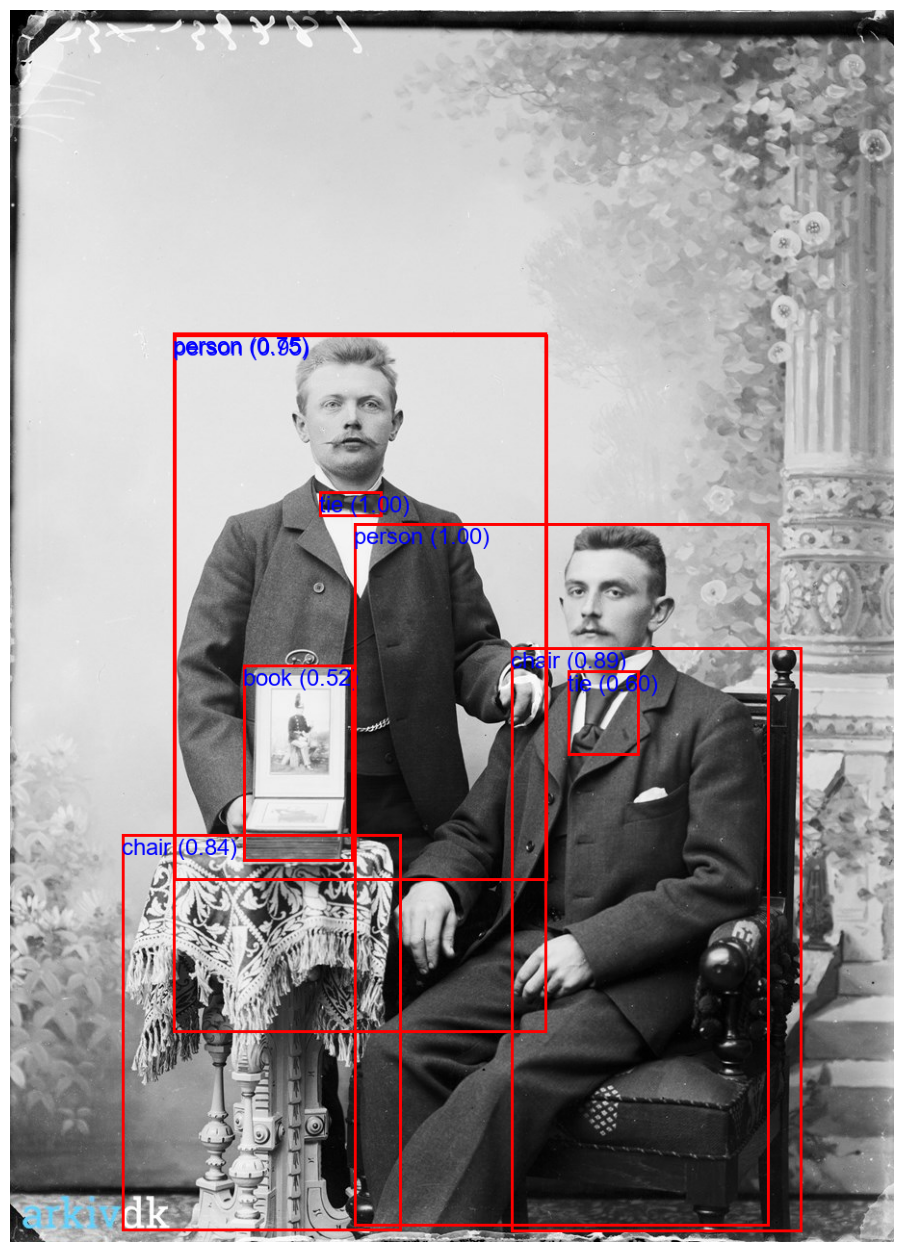

In [2]:
from utils import draw_picture # A little function I wrote to make this cleaner
draw_picture(results, "Figures/arkivdk7055378.png", (24,16))

# Demonstration 2: Natural Language Processing

### About NLP
- Natural Language Processesing used to be based on *Bag of Words* (BoW) and *rule-based* methods informed by Grammar and Lingustics
- The old approach still has some merit (simple topic models, very fast compute in financial applications, etc.)
- Instead we use *masked* tranformer language models trained on next token prediction
  + Justification: *It turns out, that you need to implicitly understand language to predict it*
 
### Language Models: Quick and dirty tour of the landscape
- Old models: Based on LSTM
- New models: Based on transformers
- Medium Language Models: 50m to 1b parameters
- Large Language Models: >1b parameters


## Demo 2.1: Sentiment analysis

In [4]:
from transformers import pipeline
classifier = pipeline("sentiment-analysis", model = "distilbert/distilbert-base-uncased-finetuned-sst-2-english")
result = classifier("It is a lot of fun to learn some pretty advanced ML stuff.")
print(result)

[{'label': 'POSITIVE', 'score': 0.9997615218162537}]


## Demo 2.2: Text generation from Large Language Model

In [1]:
from transformers import pipeline
import torch

model = pipeline(task = "text-generation", model = 'HuggingFaceH4/zephyr-7b-beta', torch_dtype=torch.bfloat16, device_map='auto') # facebook/opt-125m
result = model("The technical aspects of economic history", max_length = 50, truncation=True)

C:\Users\christian-vs\Anaconda3\envs\HISCO\Lib\site-packages\accelerate\utils\modeling.py:1384: UserWarning: Current model requires 452988288 bytes of buffer for offloaded layers, which seems does not fit any GPU's remaining memory. If you are experiencing a OOM later, please consider using offload_buffers=True.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

In [2]:
result

[{'generated_text': 'The technical aspects of economic history, such as the study of prices, wages, and interest rates, are also important in understanding the economic development of a region.\n\nIn summary, economic history is a multidisciplinary field that draws on'}]

### Extension: You can also provide context

In [6]:
messages = [
    {
        "role": "system",
        "content": "You are a friendly econometrician who's interested in advanced statistical techniques for Economic History.",
    },
    {"role": "user", "content": "Can we do good economic history research without all the technicalities?"},
]
prompt = model.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
outputs = model(prompt, max_new_tokens=128, do_sample=True, temperature=0.7, top_k=10, top_p=0.95)
print(outputs[0]["generated_text"])

<|system|>
You are a friendly econometrician who's interested in advanced statistical techniques for Economic History.</s>
<|user|>
Can we do good economic history research without all the technicalities?</s>
<|assistant|>
While advanced statistical techniques are important for conducting rigorous economic history research, it's not necessary to have a deep technical understanding of all these methods to do good economic history research.

Economic history research involves analyzing historical data to understand economic phenomena in the past. The technicalities come into play when trying to account for the complexities of historical data, such as missing values, non-linearity, and heterogeneity.

However, there are many economic history research questions that can be addressed with simpler statistical methods, such as regression analysis, time-series analysis, and difference-in-difference


# Tokens and embedding space

### Outline

#### Language
1. Tokenization: Representing text as numbers
1. Text embeddings
1. Neural networks for text data
1. Text classification from scratch

#### Vision
1. Document classification
1. Segmentations
1. Handwritten text recognition
1. Application: Copenhagen Infant Health Visitor Records

# Tokenization

**Computers only like numbers**: We need to somehow represent text as numbers

*We essentially do this the same way we handle categorical variables in regressions*

## Tokenizing a sentence

Tokenization works by building a dictionary for each word (or more generally token, it could be the sub-word or even character level).

For example, we may build the following dictionary:

In [54]:
tokenization_dict = {
    'the': 0,
    'cat': 1,
    'sat': 2,
    'on': 3,
    'mat': 4,
}

example_text = 'the cat sat on the mat'
tokenized_text = [tokenization_dict[word] for word in example_text.split()]
print(tokenized_text)

[0, 1, 2, 3, 0, 4]


## One-hot encoding

It makes little sense to think of separate words as lying on a continuous scale - and thus the numbers on the previous slide should be thought of as representing a categorical variable

As with using dummies in regressions, we now expand this categorial variable to a number of different 0/1 variables, which we call one-hot encoding

In [59]:
import torch

one_hot_encoded = torch.nn.functional.one_hot(torch.tensor(tokenized_text))
print(one_hot_encoded)

tensor([[1, 0, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 1, 0],
        [1, 0, 0, 0, 0],
        [0, 0, 0, 0, 1]])


This matrix has five columns, as we have a dictionary with five unique words, and six rows, as we have a sentence consisting of six words (of which two are the same)

If we then estimated a linear model using OLS, we could make our preditions like so

In [65]:
betas = torch.tensor([1, 2, 3, 5, 9])

one_hot_encoded @ betas

tensor([1, 2, 3, 5, 1, 9])

Typically, a neural network will consists of a series of such matrix multiplications followed by some non-linearity

**Note**: It's quite inefficient to perform the above matrix multiplication, as the first matrix is *sparse* - and in practice, we'd implement this using a lookup

In [69]:
betas_lookup = dict(zip(tokenization_dict.values(), betas))
torch.tensor([betas_lookup[token] for token in tokenized_text])

tensor([1, 2, 3, 5, 1, 9])

**Note**: Often, we'll associate a *vector* (rather than just one number) with each token

# Text embeddings

**TODO potentially place this after *Neural networks for text***

Our initial task of transforming our tokenized text into numbers is generally performed by an embedding layer - which is just a lookup table, but where the numbers to look up are optimized as part of the neural network

# Neural networks for text

We now know how to represent text as numerical data suitable for modelling. Our next objective is to learn *how* to model text data

One key observation is that text is somewhat similar to time series data, in that a **TODO sequential, correlation to nearby, ...**

Modern approaches roughly falls into one of two categories
1. Recurrent neural networks (RNNs; "classical" approach)
1. Transformers (SOTA)

We'll first consider RNNs before turning to transformer models

### A recurrent cell of a neural network

<img src="./figs/figure_6-9.png" alt="Drawing" style="width: 400px;"/>
Source: Deep Learning with Python by Francois Collet (ISBN10: 9781617294433)

We have not yet specified the type of recurrent connection, just that it has form

$y_t = f(x_t, y_{t - 1})$

We can think about an autoregressive linear model with covariates as one example

$y_t = \alpha y_{t - 1} + \beta f_t$

### Recurrent cells and unfolding

Usually, a recurrent neural network looks something like the image below - i.e., it has a "loop" where it feeds into itself (left). This can then be "unfolded" (right), in which way it looks more like a regular network, with an additional input and output ("hidden states").

<img src="./figs/Recurrent_neural_network_unfold.svg" alt="Drawing" style="width: 600px;"/>
Source: "fdeloche - Own work, CC BY-SA 4.0, https://commons.wikimedia.org/w/index.php?curid=60109157"

### Long-term dependencies

A weakness of the simple recurrent neural network is that it becomes very difficult to model long-term dependencies

To address this, different architectures have been developed, typically with the primary difference being that that output $y_t$ is no longer passed on, but instead a "hidden state" is passed along

This makes modellen long-term dependencies *much* easier, as we no longer have to rely the our output being the sole information we pass along to the next step

The most commonly used architecturs/"layers" are
1. Long short-term memory (LSTM)
1. Gated recurrent unit (GRU) 

### Long Short Term Memory (LSTM)
    
<img src="./figs/Long_Short-Term_Memory.svg" alt="Drawing" style="width: 800px;"/>
Source: "fdeloche - Own work, CC BY-SA 4.0, https://commons.wikimedia.org/w/index.php?curid=60149410"

### Gated Recurrent Unit (GRU)

<img src="./figs/Gated_Recurrent_Unit.svg" alt="Drawing" style="width: 800px;"/>
Source: "fdeloche - Own work, CC BY-SA 4.0, https://commons.wikimedia.org/w/index.php?curid=60466441"

# Text classification: HISCO classifier

 Let's build a simple HISCO classifier using the tools introduced:
 1. **Tokenization**: We'll use character-level tokenization
 1. **Embedding layer**: We'll 100-dimensional embedding space
 1. **GRU**: We'll use a GRU layer to model dependencies

 Combining these allow us to build a HISCO classifier "from scratch" which, when trained an 9000 observations, achieve >70% test accuracy

### Building a character-level tokenizer

In [23]:
from functools import partial

import torch

from torch import Tensor
from torch.utils.data import Dataset

import pandas as pd

CHARS_IN_TOYDATA = [' ', '"', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', '@', '[', ']', '_', '`', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '¢', '£', '©', '¬', 'Â', 'Ã', 'â', 'œ', 'š', 'ž', '‚', '„', '€']
MAP_CHAR_IDX = {char: idx for idx, char in enumerate(CHARS_IN_TOYDATA, start=2)}

def tokenize(hisco: str, max_len: int) -> list[int]:
    encoded = [MAP_CHAR_IDX.get(char, 0) for char in hisco]
    encoded = encoded[:max_len]
    encoded += [1] * (max_len - len(encoded))

    return encoded

*Illustrating tokenizing occupational descriptions*

In [26]:
for char, token in zip('farmer', tokenize('farmer', 6)):
    print(f'Mapping "{char}" to "{token}"')

Mapping "f" to "36"
Mapping "a" to "31"
Mapping "r" to "48"
Mapping "m" to "43"
Mapping "e" to "35"
Mapping "r" to "48"


[39, 48, 45, 44, 2, 53, 45, 48, 41, 49, 2, 42, 31, 32, 45, 51, 48, 35, 48, 1]

In [27]:
tokenize('iron works labourer', 20) # longer example

[39, 48, 45, 44, 2, 53, 45, 48, 41, 49, 2, 42, 31, 32, 45, 51, 48, 35, 48, 1]

### Building a HISCO dataset

In [22]:
class HISCODataset(Dataset):
    def __init__(self, dataset: pd.DataFrame):
        super().__init__()

        self.dataset = dataset
        self.tokenizer = partial(tokenize, max_len=32)

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, item: int) -> dict[str, str | Tensor]:
        record = self.dataset.iloc[item]
        encoded = self.tokenizer(record.occ1)

        package = {
            'occ1': record.occ1,
            'encoded': torch.tensor(encoded, dtype=torch.long),
            'label': torch.tensor(record.label, dtype=torch.long),
        }

        return package

In [30]:
import os
from dirs import DATA_DIR

train_data = pd.read_csv(os.path.join(DATA_DIR, 'toy_data_train.csv'))
train_data.head(3)

,occ1,label
0,iron works labourer,1915
1,fireman midland railway,1885
2,ironstone mine foreman,513


In [31]:
train_dataset = HISCODataset(train_data)
train_dataset[0]

{'occ1': 'iron works labourer',
 'encoded': tensor([39, 48, 45, 44,  2, 53, 45, 48, 41, 49,  2, 42, 31, 32, 45, 51, 48, 35,
         48,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1]),
 'label': tensor(1915)}

*So which HISCO code does the label 1915 refer to?*

In [35]:
from histocc import DATASETS

keys = DATASETS['keys']()
map_hisco_label = dict(keys[['hisco', 'code']].values)
map_label_hisco = {v: k for k, v in map_hisco_label.items()}

map_label_hisco[1915]

99910

*... and some other examples..*

In [39]:
for description, label in train_data.head(5).values:
    hisco = map_label_hisco[label]
    print(f'"{description}" has label {label} -> HISCO: {hisco}')

"iron works labourer" has label 1915 -> HISCO: 99910
"fireman midland railway" has label 1885 -> HISCO: 98330
"ironstone mine foreman" has label 513 -> HISCO: 22610
"engineer fitter and turner" has label 1321 -> HISCO: 83320
"carpenter deceased" has label 1751 -> HISCO: 95410


With our dataset class, we can build data loaders, which are wrappers around our dataset responsible for creating a **batch** of data

In [45]:
from torch.utils.data import DataLoader

test_data = pd.read_csv(os.path.join(DATA_DIR, 'toy_data_test.csv'))
test_dataset = HISCODataset(test_data)

train_data_loader = DataLoader(train_dataset, batch_size=32)
test_data_loader = DataLoader(test_dataset, batch_size=32)

### Building a HISCO classifier

**Goal**: Given an occupational description, provide its associated HISCO

In [40]:
from torch import Tensor, nn


class HISCOClassifier(nn.Module):
    def __init__(self, vocab_size: int = 100, hidden_size: int = 128):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.classifier = nn.Linear(hidden_size, 1919)

    def forward(self, input_seq: Tensor) -> Tensor:
        out = self.embedding(input_seq)
        out, _ = self.gru(out)
        out = out[:, -1, :]
        out = self.classifier(out)

        return out


We can can instantiate our **model**; we also need an objective (or **loss**) function and an **optimizer**

In [42]:
model = HISCOClassifier()

# For single-label classification, cross entropy is the
# standard loss function to use. This has the limitation
# that it only allows ONE HISCO code for an occupational
# description
loss_fn = torch.nn.CrossEntropyLoss()

# Adam/AdamW are common types of optimizers. An optimizer
# is responsible for how we choose, based on derivatives
# with respect to our loss function, to update the para-
# meters of our model
optimizer = torch.optim.AdamW(model.parameters(), lr=0.01)

### Building a training loop

We now train our model by iteratively
1. Draw a **batch** of descriptions and labels
1. Make our model *predict* the labels given the descriptions
1. Calculate the loss wrt. the predictions and labels
1. Calculate the derivative of the loss wrt. the model parameters
1. Update the model parameters

In [43]:
def train_epoch(model, optimizer, data_loader, loss_fn):
    model.train()

    for batch in data_loader:
        optimizer.zero_grad()
        
        out = model(batch['encoded']) # make predictions
        loss = loss_fn(out, batch['label']) # calculate loss
        loss.backward() # calculate derivatives

        optimizer.step() # update network parameters

### Building an evaluation loop

Ultimately, we want to evaluate our model in terms of how often it corretly predicts a HISCO code given an occupational description

In [44]:
@torch.no_grad
def evaluate(model, data_loader):
    model.eval()

    total_correct = 0 # keep count of correct predictions
    total_count = 0 # keep count of total number of predictions

    for batch in data_loader:
        out = model(batch['encoded']).argmax(1)

        total_correct += (out == batch['label']).sum().item()
        total_count += batch['label'].size(0)

    return total_correct / total_count # calculate accuracy

### Training our HISCO classifier

We now train our model by looping over the training data 10 times

In [49]:
for epoch in range(1, 11):
    train_epoch(model, optimizer, train_data_loader, loss_fn)
    acc = evaluate(model, test_data_loader)
    
    print(f'Trained for {epoch} epochs. Validation accuracy: {100 * acc}%')

Trained for 1 epochs. Validation accuracy: 73.8%
Trained for 2 epochs. Validation accuracy: 73.4%
Trained for 3 epochs. Validation accuracy: 74.6%
Trained for 4 epochs. Validation accuracy: 75.2%
Trained for 5 epochs. Validation accuracy: 74.1%
Trained for 6 epochs. Validation accuracy: 75.7%
Trained for 7 epochs. Validation accuracy: 75.9%
Trained for 8 epochs. Validation accuracy: 77.2%
Trained for 9 epochs. Validation accuracy: 77.5%
Trained for 10 epochs. Validation accuracy: 76.4%


*if we were to always predict the most common class, we would only achieve 10% accuracy*

**TODO EXERCISE HERE, EXPERIMENTING ON TOY DATASET**

# Transcription of Handwritten Data

**TODO potentially motivation ehre*

## Document Digitization

**Ambition**: Make any source of handwritten data as readily available for analysis as register data

<img src="./figs/pipeline.jpg" alt="Drawing" style="width: 800px;"/>

## From Source to Output

<img src="./figs/hana-transcription.png" alt="Drawing" style="width: 800px;"/>

#### Visition Transformer Encoder/Transformer Decoder

<img src="./figs/vit_enc_transformer_dec_v2.png" alt="Drawing" style="width: 800px;"/>

## Prerequisites

ML works by learning from data - as such, we need good models *and* data

<div style="display: flex; justify-content: space-around; margin-top: 10px;">
    <div style="text-align: center; width: 45%;">
        <strong>Models</strong>
    </div>
    <div style="text-align: center; width: 45%;">
        <strong>Data</strong>
    </div>
</div>

<div style="display: flex; justify-content: space-around; margin-top: 10px;">
    <div style="width: 45%;">
        Generalizable, accurate models
        <ul>
            <li>High-level pipeline for end-to-end digitization</li>
            <li>HTR models achieving super-human performance</li>
        </ul>
        <p style="font-size: small;">
            <a href="https://doi.org/10.1080/01615440.2023.2164879" target="_blank">https://doi.org/10.1080/01615440.2023.2164879</a>
        </p>
    </div>
    <div style="width: 45%;">
        Large-scale, high-quality datasets
        <ul>
            <li><strong>HANA</strong>: Largest dataset of handwritten names</li>
            <li><strong>DARE</strong>: Largest dataset of handwritten dates</li>
        </ul>
        <p style="font-size: small;">
            <a href="https://doi.org/10.1016/j.eeh.2022.101473" target="_blank">https://doi.org/10.1016/j.eeh.2022.101473</a>
        </p>
    </div>
</div>


## Performance: Dates

<div style="text-align: center;">
    <img src="./figs/dc-dates.PNG" alt="Dates Performance" style="width: 100%;">
</div>

<table style="width: 100%; margin-top: 10px; border-collapse: collapse;">
    <thead>
        <tr>
            <th></th>
            <th>Date</th>
            <th>Day</th>
            <th>Month</th>
            <th>Year</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>Out-of-the-box</td>
            <td>73.9</td>
            <td></td>
            <td></td>
            <td></td>
        </tr>
        <tr>
            <td>ML ('19)</td>
            <td>90.5</td>
            <td>96.0</td>
            <td>97.0</td>
            <td>97.2</td>
        </tr>
        <tr>
            <td>Crowd sourcing</td>
            <td>96.3</td>
            <td>98.3</td>
            <td>98.7</td>
            <td>98.8</td>
        </tr>
        <tr>
            <td>ML ('22)</td>
            <td>97.7</td>
            <td>99.2</td>
            <td>99.0</td>
            <td>99.2</td>
        </tr>
    </tbody>
</table>

<p style="text-align: center; font-size: small;">
    Transcription Accuracy (%). "Out-of-the-box" performance refers to <i>Transkribus</i> (<a href="https://readcoop.eu/transkribus/" target="_blank">https://readcoop.eu/transkribus/</a>).
</p>


## Performance: Names

<div style="text-align: center;">
    <img src="./figs/montage_grid_names_2x2_black.jpg" alt="Names Performance" style="width: 100%;">
</div>

<table style="width: 100%; margin-top: 10px; border-collapse: collapse;">
    <thead>
        <tr>
            <th></th>
            <th colspan="2" style="text-align: center;">Character Error Rate</th>
            <th colspan="2" style="text-align: center;">Sequence Error Rate</th>
        </tr>
        <tr>
            <th></th>
            <th>First name</th>
            <th>Last name</th>
            <th>First name</th>
            <th>Last name</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>ML ('20)</td>
            <td>1.4</td>
            <td>1.5</td>
            <td>4.9</td>
            <td>5.7</td>
        </tr>
        <tr>
            <td style="padding-left: 5px;">matched</td>
            <td>1.5</td>
            <td>1.5</td>
            <td>4.4</td>
            <td>4.3</td>
        </tr>
        <tr>
            <td>ML ('22)</td>
            <td></td>
            <td>0.9</td>
            <td></td>
            <td>3.2</td>
        </tr>
    </tbody>
</table>

<p style="text-align: center; font-size: small;">
    Transcription Accuracy (%).
</p>


## **Application**: Copenhagen Infant Health Visitor Records (CIHVR)

**What?** → collection of nurse records part of the Danish nurse home visiting programme

**When and where?** → everyone living in CPH born 1959-1967

<div style="text-align: center; margin-top: 20px;">
    <img src="figs/nhr_record.png" alt="Nurse Home Record" style="width: 100%;">
</div>


## Nurse Home Visiting in Denmark

Started in 1937 to reduce infant mortality, the National Board of Health felt the need to modernize the program in the 1950s

<div style="margin-top: 10px;">
    This led to several trials, the purpose of which was to guide policy makers regarding how to modernize the program 
</div>

<div style="text-align: center; margin-top: 20px;">
    <img src="./figs/shpbillede.jpg" alt="Image 1" style="width: 22%; margin-right: 1%;">
    <img src="./figs/shp_5.jpg" alt="Image 2" style="width: 22%; margin-right: 1%;">
    <img src="./figs/shp_3.jpg" alt="Image 3" style="width: 22%; margin-right: 1%;">
    <img src="./figs/shp_2.jpg" alt="Image 4" style="width: 22%;">
</div>

<div style="text-align: center; margin-top: 10px; font-size: small;">
    Source: <i>Museum of Copenhagen; pictures taken in 1940s</i>
</div>


## CIHVR - Digitization Process

<div style="text-align: center;">
    <img src="./figs/cihvr-transcription.PNG" alt="CIHVR Transcription Process" style="width: 100%;">
</div>

<div style="margin-top: 10px; font-size: small; text-align: center;">
    Source: <i>Lise G Bjerregaard, Miriam Wüst, Torben S D Johansen, Thorkild I A Sørensen, Christian M Dahl, Jennifer L Baker, Cohort Profile: The Copenhagen Infant Health Nurse Records (CIHNR) cohort, International Journal of Epidemiology, Volume 52, Issue 6, December 2023, Pages e340–e346, <a href="https://doi.org/10.1093/ije/dyad096" target="_blank">https://doi.org/10.1093/ije/dyad096</a></i>
</div>


## Step 1: Clustering the Documents

Using unsupervised ML, we can cluster the ~280,000 documents into separate types

<img src=./figs/clustering.png alt="Drawing" style="width: 600px;"/>

## Step 2: Image Segmentation (Point Drift)

<img src="./figs/large-im-cropped.png" alt="Drawing" style="width: 600px;"/>

## Step 2: Image Segmentation (Point Drift)

<img src="./figs/stacked-grids.png" alt="Drawing" style="width: 600px;"/>

## Step 2: Image Segmentation (Point Drift)

<img src="./figs/stacked-grid-points.png" alt="Drawing" style="width: 600px;"/>

## Step 2: Image Segmentation (Point Drift)

<img src="./figs/large-im-cropped-points.png" alt="Drawing" style="width: 600px;"/>

## Step 2: Image Segmentation (Point Drift)

<img src="./figs/cpd-gif.gif" alt="Drawing" style="width: 600px;"/>

## Step 2: Image Segmentation (Point Drift)

<img src="./figs/transformed-large-im-overlay-handcropped.png" alt="Drawing" style="width: 600px;"/>

## Step 3: Transcription

<img src="./figs/montage-weight.png" alt="Drawing" style="width: 600px;"/>

## Research Question

**RQ**: What are the long-run impact of universal preventive care for toddlers?

**How**: Our analyses compare the outcomes of children exposed to *a three year vs. one year* nurse home visiting program in the 1960s in Copenhagen

<div style="margin-top: 10px;">
    In contrast to earlier studies using large-scale data, we use individual-level exposure.
    How? Using CIHVR and exploiting a large-scale trial
</div>

<div style="margin-top: 10px;">
    <ul>
        <li><u>Data</u>: Transcribed handwritten nurse records, historical cohort data, and population administrative data</li>
        <li><u>Identifying variation</u>: A trial at scale in the municipality of Copenhagen assigning a "random" subset of children to extended care</li>
    </ul>
</div>


## Did the treatment assignment work? Yes!

<div style="text-align: center;">
    <img src="./figs/share_longtable_matched_by_day.png" alt="Treatment Assignment" style="width: 80%;">
</div>


## Childhood health

<div style="text-align: center;">
    <div style="display: inline-block; width: 49%;">
        <img src="./figs/graph_vaccanti.png" alt="Vacc. and antibiotics use" style="width: 100%;">
        <div>Vacc. and antibiotics use</div>
    </div>
    <div style="display: inline-block; width: 49%;">
        <img src="./figs/graph_hosp_disease.png" alt="Hosp. adm. and inf. disease" style="width: 100%;">
        <div>Hosp. adm. and inf. disease</div>
    </div>
</div>

**Significantly less antibiotics usage** - some evidence of more vaccinated; fewer hospital admissions and infectious diseases


## Survival - Observed Deaths

<div style="text-align: center;">
    <img src="./figs/km_observeddeaths_pretty.png" alt="Observed Deaths" style="width: 80%;">
</div>

**ATET**: 13% (sample mean of 8.3%)

## Breastfeeding and long-run socioeconomic outcomes

The CPH Nurse Records allow us to conduct the largest ever prospectively collected, population-based study on associations between duration and intensity of breastfeeding and adulthood socioeconomic outcomes.

<div style="text-align: center; margin-top: 20px;">
    <img src="./figs/bf-and-edulen.png" alt="Breastfeeding and Education" style="width: 60%;">
    <div style="font-size: small; margin-top: 10px;">
        <i>Differences in years of education by duration of breastfeeding. Results reported separately by mother education.</i>
    </div>
</div>


## Link-Lives -- "Register Data" back to 1787

<span style="color: blue;">Link-Lives</span> is a project that aims to extend Danish "register data" back to 1787 by reconstructing life-courses and family relations of everyone living in Denmark from 1787.

**How?**
<div style="margin-top: 10px;">
    <ol>
        <li>Transcribing individual-level information from censuses, birth records, death certificates, conscription records, patient records, autobiographies, ...</li>
        <li>Linking individuals together to construct the complete Danish population tree of the last ≈ 250 years</li>
    </ol>
</div>

<div style="margin-top: 50px; display: flex; justify-content: space-between;">
    <div style="width: 48%; font-size: small;">
        <a href="https://link-lives.dk/en/about-link-lives/" target="_blank">https://link-lives.dk/en/about-link-lives/</a>
    </div>
    <div style="width: 48%; text-align: center;">
        <img src="./figs/ll.svg" alt="Link-Lives" style="width: 50%;">
    </div>
</div>


## Transcription at Scale

As part of <span style="color: blue;">Link-Lives</span>, we have transcribed the 1890, 1911, 1916, 1921, and 1925 full-count censuses

<ol>
    <li><strong>Resources</strong>: Partial transcriptions of some sources</li>
    <li><strong>Scale</strong>: ≈ 250M segmented and transcribed images</li>
    <li><strong>Performance</strong>: Heterogeneous & data-dependent</li>
</ol>

<div style="text-align: center; margin-top: 20px;">
    <img src="./figs/1925-0-shot-non-empty-3x1.png" alt="Zero-shot transcription examples" style="width: 100%;">
    <div style="font-size: small; margin-top: 10px;"><i>Zero-shot transcription examples</i></div>
</div>


# More papers to read
- Dell, M. (2024). Deep learning for economists. arXiv. [https://arxiv.org/abs/2407.15339]
- Yanagizawa-Drott, D., & Voth, H. J. (2024). Image(s). [https://www.jvoth.com/images_july_24.pdf]